In [ ]:
ret_12m

Nombre total de tickers: 407


In [6]:
data[data['OfferPrice'] > 5]

,ticker,year,open_px,close_px,underpricing,ret_30d,ipo_size_m,fed_rate,sic,sector,...,revenue_ltm,profitable,ret_12m_flag,ipo_date,OfferPrice,Size_Million,Date,FilingUrl,ret_12m,ret_12m.1
0,PINS,2019,23.750000,24.400000,0.027368,0.000000,2068.850625,2.16,7370.0,Tech,...,1142.761,0.0,ok,2019-04-18,19.0,1425.000000,2019-04-18T17:22:46-04:00,https://www.sec.gov/Archives/edgar/data/150629...,-0.284836,-0.284836
1,REAL,2019,28.000000,28.900000,0.032143,-0.381315,550.765600,2.16,5900.0,Consumer,...,316.354,0.0,ok,2019-06-28,20.0,300.000000,2019-06-28T06:07:10-04:00,https://www.sec.gov/Archives/edgar/data/157322...,-0.536332,-0.536332
2,SNDL,2019,130.199997,84.800003,-0.348694,0.031840,121.273485,2.16,2833.0,Industrials,...,NaN,NaN,ok,2019-08-01,13.0,143.000000,2019-08-01T11:12:51-04:00,https://www.sec.gov/Archives/edgar/data/176660...,-0.932311,-0.932311
3,PGNY,2019,13.500000,15.940000,0.180741,0.744668,67.140900,2.16,8090.0,Healthcare,...,65.122,0.0,ok,2019-10-25,13.0,130.000000,2019-10-25T16:44:36-04:00,https://www.sec.gov/Archives/edgar/data/155130...,0.753451,0.753451
4,SITM,2019,13.000000,13.000000,0.000000,0.961538,0.001300,2.16,3674.0,Industrials,...,28.089,1.0,ok,2019-11-20,13.0,55.900000,2019-11-21T16:55:16-05:00,https://www.sec.gov/Archives/edgar/data/145180...,5.213077,5.213077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402,MRX,2024,18.907046,18.412554,-0.026154,0.053712,137.437208,5.14,6200.0,Finance,...,1924.200,1.0,ok,2024-04-25,19.0,292.307685,2024-04-25T19:31:09-04:00,https://www.sec.gov/Archives/edgar/data/199746...,1.347062,1.347062
403,GUTS,2024,13.750000,12.850000,-0.065455,-0.513619,40.521250,5.14,3841.0,Industrials,...,0.000,0.0,ok,2024-02-02,15.0,109.999995,2024-02-02T16:18:22-05:00,https://www.sec.gov/Archives/edgar/data/157261...,-0.880545,-0.880545
404,IBAC,2024,9.960000,9.980000,0.002008,-0.001002,0.026892,5.14,6770.0,Finance,...,0.000,1.0,ok,2024-05-01,10.0,100.000000,2024-03-27T17:28:06-04:00,https://www.sec.gov/Archives/edgar/data/199878...,0.038076,0.038076
405,DTSQ,2024,9.980000,9.970000,-0.001002,0.004012,2.194602,5.14,6770.0,Finance,...,0.000,1.0,ok,2024-09-16,10.0,60.000000,2024-07-26T08:56:04-04:00,https://www.sec.gov/Archives/edgar/data/201795...,0.052156,0.052156


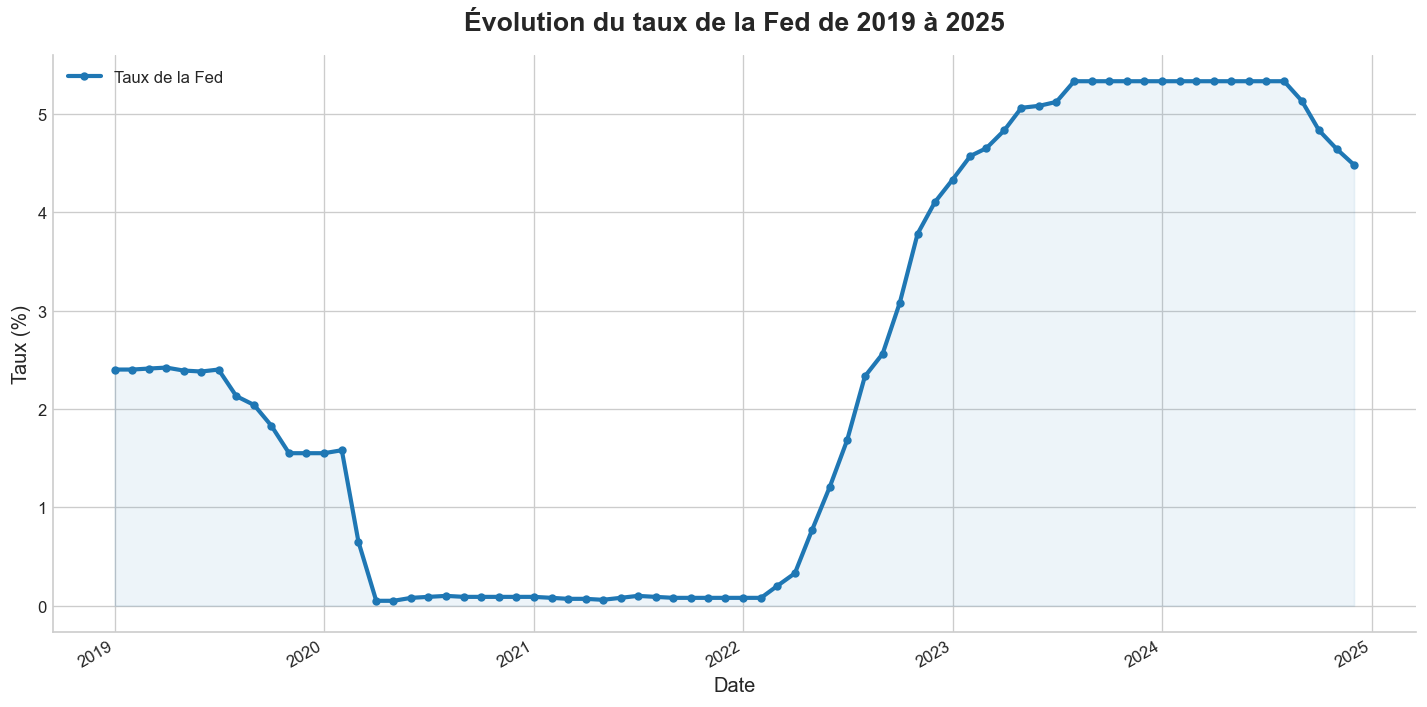

In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Préparation des données
data['date'] = pd.to_datetime(data['date'])
df = data.sort_values('date')

# Style du graphique
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

ax.plot(
    df['date'],
    df['fed_rate'],
    color='#1f77b4',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Taux de la Fed'
)

ax.fill_between(df['date'], df['fed_rate'], color='#1f77b4', alpha=0.08)

ax.set_title('Évolution du taux de la Fed de 2019 à 2025', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Taux (%)', fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [3]:
# Résumé annuel à partir du bon fichier et des bonnes colonnes

yearly_summary = (
    data.groupby('year')
    .agg({
        'ticker': 'count',
        'underpricing': 'mean',
        'company_age': 'median',
        'fed_rate': 'mean'
    })
    .rename(columns={
        'ticker': 'N (IPO traditionnelles)',
        'underpricing': 'Underpricing moyen',
        'company_age': 'Âge médian (ans)',
        'fed_rate': 'Taux Fed moyen (%)'
    })
    .reset_index()
    .rename(columns={'year': 'Année'})
)

yearly_summary['Underpricing moyen'] = yearly_summary['Underpricing moyen'].map(lambda value: f"{value:+.2f} %".replace('.', ','))
yearly_summary['Âge médian (ans)'] = yearly_summary['Âge médian (ans)'].map(lambda value: f"{value:g}".replace('.', ','))
yearly_summary['Taux Fed moyen (%)'] = yearly_summary['Taux Fed moyen (%)'].map(lambda value: f"{value:.2f}".replace('.', ','))

yearly_summary

,Année,N (IPO traditionnelles),Underpricing moyen,Âge médian (ans),Taux Fed moyen (%)
0,2019,71,"+0,03 %",10,"2,16"
1,2020,96,"+0,02 %",8,"0,38"
2,2021,104,"+0,01 %",11,"0,08"
3,2022,18,"-0,04 %",12,"1,68"
4,2023,32,"-0,01 %","10,5","5,02"
5,2024,86,"-0,00 %","13,5","5,14"


In [7]:
import os
import re
import pandas as pd
from sec_api import QueryApi, DownloadApi

# Clé API
API_KEY = "bc7a047a8ea015c0b9ba8197fbecdd4bd1aed164802e3a8dd7f4a7958d802ee9"


query_api = QueryApi(api_key=API_KEY)
download_api = DownloadApi(api_key=API_KEY)

# Votre liste de tickers
tickers = ["ABNB", "SNOW", "CRWD"]

# Motifs de détection
spac_patterns = [
    r"blank check",
    r"special purpose acquisition company",
    r"\bspac\b"
]

direct_patterns = [
    r"direct listing",
    r"directly listed",
    r"direct public offering"
]

def search_filings_for_ticker(ticker):
    search_params = {
        "query": f'ticker:{ticker} AND (formType:"S-1" OR formType:"F-1" OR formType:"424B4" OR formType:"EFFECT" OR formType:"8-K")',
        "from": "0",
        "size": "10",
        "sort": [{"filedAt": {"order": "desc"}}]
    }
    return query_api.get_filings(search_params).get("filings", [])

def detect_listing_type(filings):
    is_spac = False
    is_direct_listing = False
    evidence = ""

    for filing in filings:
        txt_url = filing.get("linkToTxt")
        if not txt_url:
            continue

        try:
            text = download_api.get_file(txt_url).lower()
        except Exception:
            continue

        if any(re.search(pattern, text) for pattern in spac_patterns):
            is_spac = True
            evidence = "SPAC détecté dans le texte du filing"
            break

        if any(re.search(pattern, text) for pattern in direct_patterns):
            is_direct_listing = True
            evidence = "Direct listing détecté dans le texte du filing"
            break

    return is_spac, is_direct_listing, evidence

results = []

for ticker in tickers:
    filings = search_filings_for_ticker(ticker)
    is_spac, is_direct_listing, evidence = detect_listing_type(filings)

    results.append({
        "ticker": ticker,
        "nb_filings_trouves": len(filings),
        "is_spac": is_spac,
        "is_direct_listing": is_direct_listing,
        "evidence": evidence,
        "latest_filing_url": filings[0].get("linkToFilingDetails") if filings else None
    })

df_result = pd.DataFrame(results)
print(df_result)

  ticker  nb_filings_trouves  is_spac  is_direct_listing evidence  \
0   ABNB                  10    False              False            
1   SNOW                  10    False              False            
2   CRWD                  10    False              False            

                                   latest_filing_url  
0  https://www.sec.gov/Archives/edgar/data/155972...  
1  https://www.sec.gov/Archives/edgar/data/164014...  
2  https://www.sec.gov/Archives/edgar/data/153552...  


In [13]:
# data[data['year'] >= 2022]
data[data['ret_12m'] > 0]



,ticker,year,open_px,close_px,underpricing,ret_30d,ipo_size_m,fed_rate,sic,sector,...,revenue_ltm,profitable,ret_12m_flag,ipo_date,OfferPrice,Size_Million,Date,FilingUrl,ret_12m,ret_12m.1
3,PGNY,2019,13.500000,15.940000,0.180741,0.744668,67.140900,2.16,8090.0,Healthcare,...,65.122,0.0,ok,1970-01-01 01:00:43.763,13.0,130.000000,2019-10-25T16:44:36-04:00,https://www.sec.gov/Archives/edgar/data/155130...,0.753451,0.753451
4,SITM,2019,13.000000,13.000000,0.000000,0.961538,0.001300,2.16,3674.0,Industrials,...,28.089,1.0,ok,1970-01-01 01:00:43.789,13.0,55.900000,2019-11-21T16:55:16-05:00,https://www.sec.gov/Archives/edgar/data/145180...,5.213077,5.213077
6,TW,2019,33.162919,34.663288,0.045242,0.208880,1083.160644,2.16,6200.0,Finance,...,197.308,1.0,ok,1970-01-01 01:00:43.559,27.0,1080.000000,2019-04-05T17:24:29-04:00,https://www.sec.gov/Archives/edgar/data/175873...,0.285032,0.285032
8,SPT,2019,18.049999,16.600000,-0.080332,-0.033133,98.253366,2.16,7372.0,Tech,...,102.707,0.0,ok,1970-01-01 01:00:43.812,17.0,150.000010,2019-12-13T16:46:12-05:00,https://www.sec.gov/Archives/edgar/data/151737...,1.786145,1.786145
9,GOTU,2019,12.100000,10.480000,-0.133884,-0.013359,165.477185,2.16,8200.0,Other,...,303.780,1.0,ok,1970-01-01 01:00:43.622,10.5,207.900000,2019-06-06T13:38:15-04:00,https://www.sec.gov/Archives/edgar/data/176825...,2.950382,2.950382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401,LOAR,2024,45.000000,48.799999,0.084444,0.210246,313.429500,5.14,3728.0,Industrials,...,218.102,1.0,ok,1970-01-01 01:00:45.407,28.0,308.000000,2024-04-26T16:18:56-04:00,https://www.sec.gov/Archives/edgar/data/200017...,0.959016,0.959016
402,MRX,2024,18.907046,18.412554,-0.026154,0.053712,137.437208,5.14,6200.0,Finance,...,1924.200,1.0,ok,1970-01-01 01:00:45.407,19.0,292.307685,2024-04-25T19:31:09-04:00,https://www.sec.gov/Archives/edgar/data/199746...,1.347062,1.347062
404,IBAC,2024,9.960000,9.980000,0.002008,-0.001002,0.026892,5.14,6770.0,Finance,...,0.000,1.0,ok,1970-01-01 01:00:45.413,10.0,100.000000,2024-03-27T17:28:06-04:00,https://www.sec.gov/Archives/edgar/data/199878...,0.038076,0.038076
405,DTSQ,2024,9.980000,9.970000,-0.001002,0.004012,2.194602,5.14,6770.0,Finance,...,0.000,1.0,ok,1970-01-01 01:00:45.551,10.0,60.000000,2024-07-26T08:56:04-04:00,https://www.sec.gov/Archives/edgar/data/201795...,0.052156,0.052156
